Assignment 8

First I will import the necessary modules to complete the assignment

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Next I will import the data and print the head for initial investigation

In [4]:
url = "https://raw.githubusercontent.com/dwaynewebb86/IS362_Assignment8/main/agaricus-lepiota.data"

df = pd.read_csv(url, header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


Now I will assign column names based on the information provided in the names file

In [5]:
columns = [
    "class", "cap-shape", "cap-surface", "cap-color", "bruises",
    "odor", "gill-attachment", "gill-spacing", "gill-size",
    "gill-color", "stalk-shape", "stalk-root",
    "stalk-surface-above-ring", "stalk-surface-below-ring",
    "stalk-color-above-ring", "stalk-color-below-ring",
    "veil-type", "veil-color", "ring-number", "ring-type",
    "spore-print-color", "population", "habitat"
]

df.columns = columns

df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


Now I will analyze  the columns class, odor, and cap shape to explore their distributions and examine how they relate to whether a mushroom is edible or poisonous.

In [6]:
df_subset = df[["class", "odor", "cap-shape"]]
df_subset.head()

,class,odor,cap-shape
0,p,p,x
1,e,a,x
2,e,l,b
3,p,p,x
4,e,n,x


Now I will convert the categorical codes in the data to numeric values. This step is required because the data will later be used with scikit-learn, which requires numerical input.

In [7]:
df_encoded = df_subset.copy()

df_encoded["class"] = df_encoded["class"].map({"e": 0, "p": 1})

df_encoded["odor"] = df_encoded["odor"].astype("category").cat.codes
df_encoded["cap-shape"] = df_encoded["cap-shape"].astype("category").cat.codes

df_encoded.head()

,class,odor,cap-shape
0,1,6,5
1,0,0,5
2,0,3,0
3,1,6,5
4,0,5,5


Now that the selected columns have been converted into numeric values, I will perform exploratory data analysis to review the distribution of class, odor, and cap-shape. This will help show how the values are spread out and whether odor or cap-shape may be useful in predicting if a mushroom is edible or poisonous.

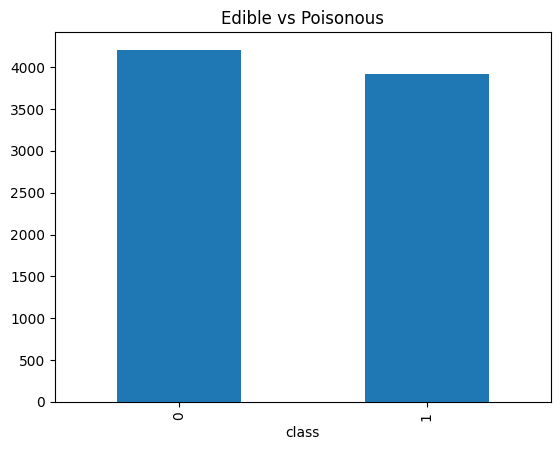

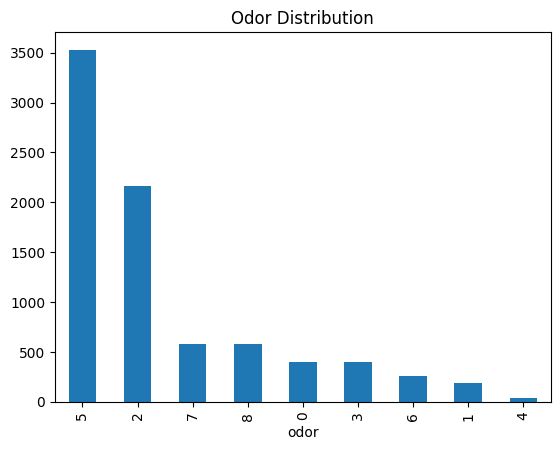

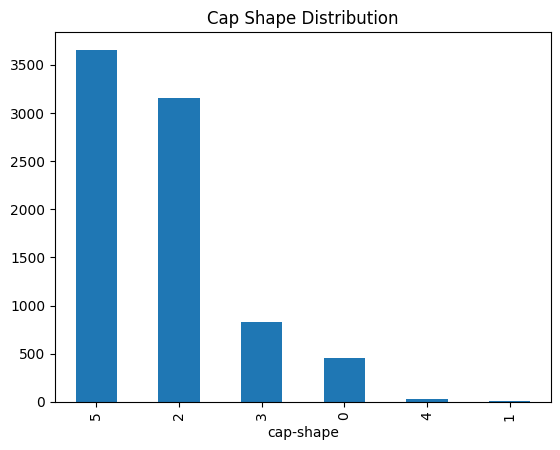

In [8]:
df_encoded["class"].value_counts().plot(kind="bar", title="Edible vs Poisonous")
plt.show()

df_encoded["odor"].value_counts().plot(kind="bar", title="Odor Distribution")
plt.show()

df_encoded["cap-shape"].value_counts().plot(kind="bar", title="Cap Shape Distribution")
plt.show()

Here I will create scatterplots to compare the class column against odor and cap-shape. These plots will help provide an early view of whether either selected feature has a relationship with whether the mushroom is edible or poisonous.

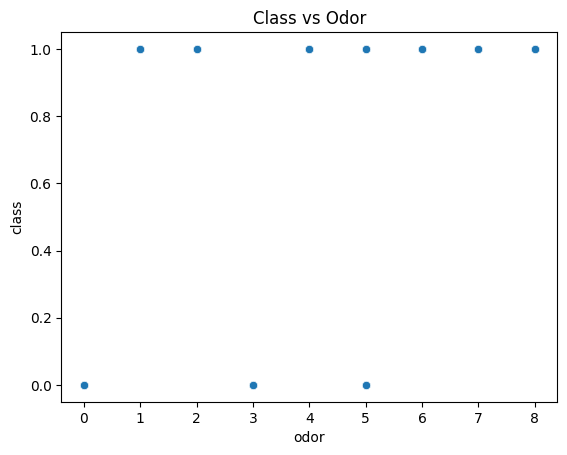

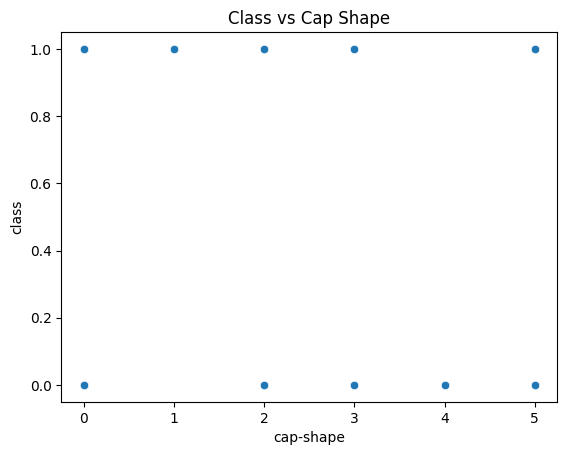

In [11]:
sns.scatterplot(data=df_encoded, x="odor", y="class")
plt.title("Class vs Odor")
plt.show()

sns.scatterplot(data=df_encoded, x="cap-shape", y="class")
plt.title("Class vs Cap Shape")
plt.show()

Based on the analysis, I can see that odor has a strong relationship with whether a mushroom is edible or poisonous. Certain odor values appear more frequently with poisonous mushrooms, which suggests that odor could be a useful feature for predicting the class of a mushroom.

When looking at cap-shape, I do not see a strong relationship with the class variable. Both edible and poisonous mushrooms appear across different cap-shape values without a clear pattern. This suggests that cap-shape may not be a strong predictor on its own.